In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
train=pd.read_csv('C:/python/DMart/Train.csv')
test=pd.read_csv('C:/python/DMart/test.csv')

In [6]:
train_original=train.copy()
test_original=test.copy()

In [7]:
train.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

In [8]:
train.shape

(8523, 12)

In [9]:
test.shape

(5681, 11)

In [10]:
train.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [11]:
train['Item_Outlet_Sales'].value_counts()

Item_Outlet_Sales
958.7520     17
1342.2528    16
703.0848     15
1845.5976    15
1278.3360    14
             ..
4124.6310     1
6622.7126     1
1614.5650     1
5602.7070     1
2778.3834     1
Name: count, Length: 3493, dtype: int64

In [12]:
train['Item_Outlet_Sales'].value_counts(normalize=True)

Item_Outlet_Sales
958.7520     0.001995
1342.2528    0.001877
703.0848     0.001760
1845.5976    0.001760
1278.3360    0.001643
               ...   
4124.6310    0.000117
6622.7126    0.000117
1614.5650    0.000117
5602.7070    0.000117
2778.3834    0.000117
Name: proportion, Length: 3493, dtype: float64

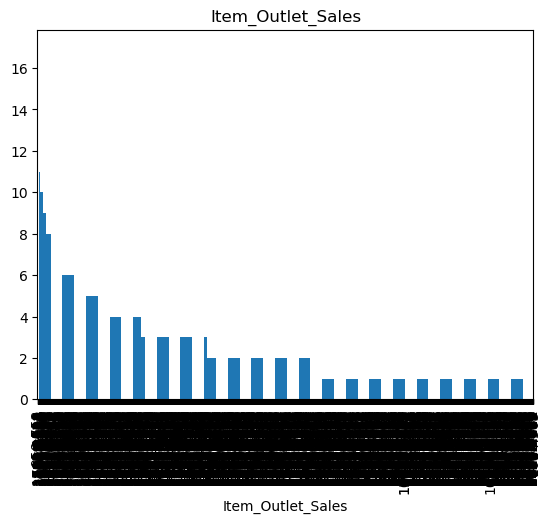

In [13]:
train['Item_Outlet_Sales'].value_counts().plot.bar(title='Item_Outlet_Sales')
plt.show()

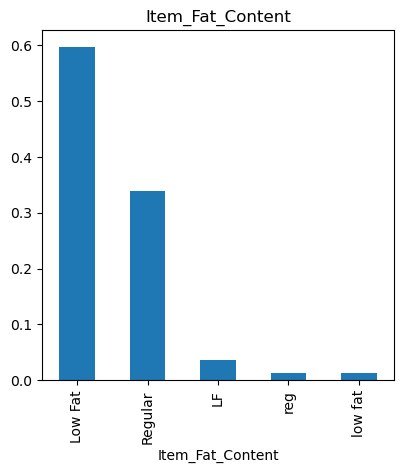

In [14]:
plt.figure(1)
plt.subplot(221)
train['Item_Fat_Content'].value_counts(normalize=True).plot.bar(figsize=(10,10),title='Item_Fat_Content')
plt.show()

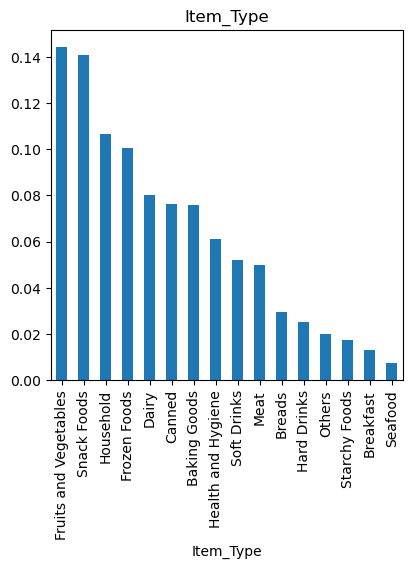

In [15]:
plt.figure(1)
plt.subplot(221)
train['Item_Type'].value_counts(normalize=True).plot.bar(figsize=(10,10),title='Item_Type')
plt.show()

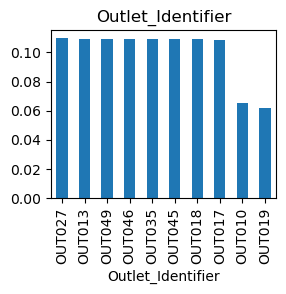

In [16]:
plt.subplot(222)
train['Outlet_Identifier'].value_counts(normalize=True).plot.bar(title='Outlet_Identifier')
plt.show()

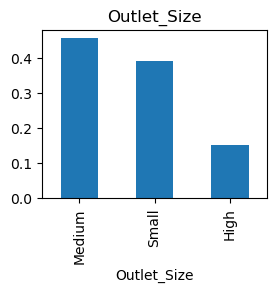

In [17]:
plt.subplot(222)
train['Outlet_Size'].value_counts(normalize=True).plot.bar(title='Outlet_Size')
plt.show()

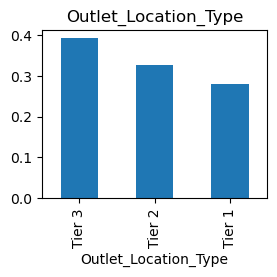

In [18]:
plt.subplot(222)
train['Outlet_Location_Type'].value_counts(normalize=True).plot.bar(title='Outlet_Location_Type')
plt.show()

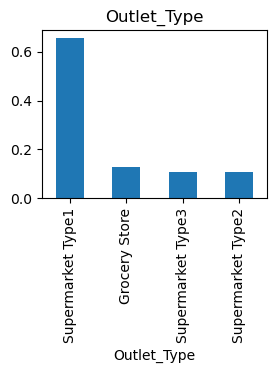

In [19]:
plt.subplot(222)
train['Outlet_Type'].value_counts(normalize=True).plot.bar(title='Outlet_Type')
plt.show()

C:\Users\sujit\AppData\Local\Temp\ipykernel_12716\3282969538.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Item_Weight'])


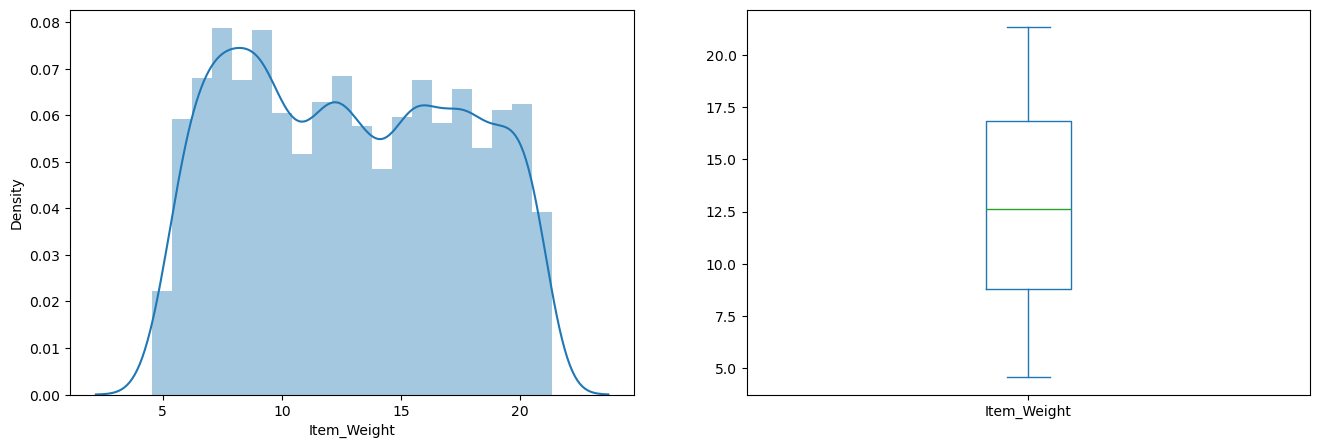

In [20]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['Item_Weight'])

plt.subplot(122)
train['Item_Weight'].plot.box(figsize=(16,5))
plt.show()

C:\Users\sujit\AppData\Local\Temp\ipykernel_12716\763673247.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Item_Visibility'])


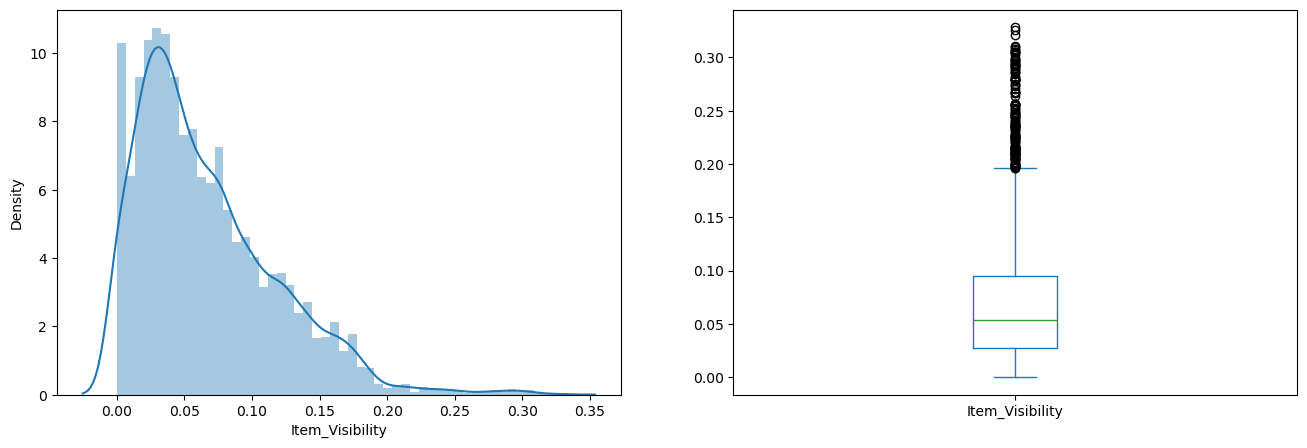

In [21]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['Item_Visibility'])

plt.subplot(122)
train['Item_Visibility'].plot.box(figsize=(16,5))
plt.show()

C:\Users\sujit\AppData\Local\Temp\ipykernel_12716\2946296707.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Item_MRP'])


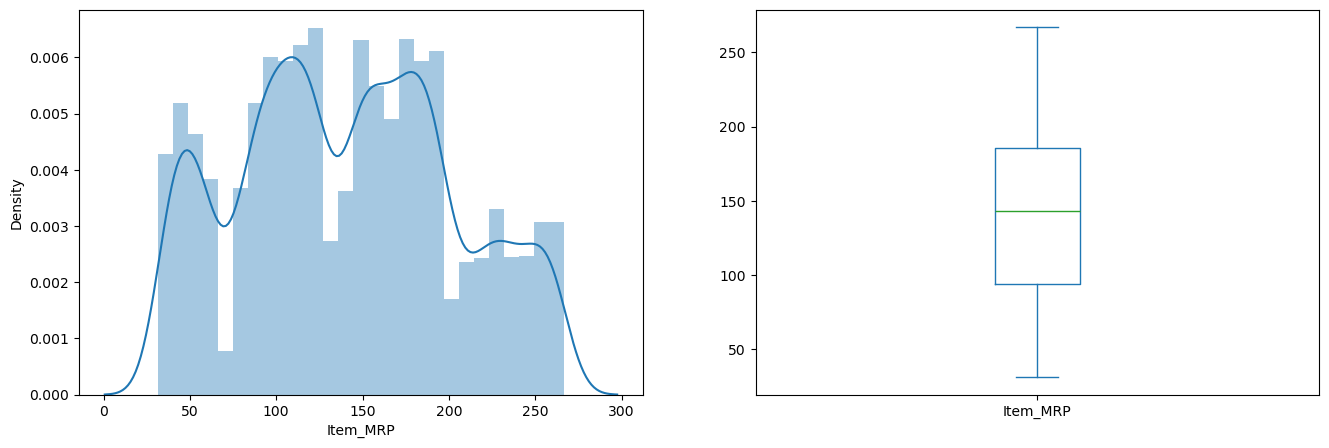

In [22]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['Item_MRP'])

plt.subplot(122)
train['Item_MRP'].plot.box(figsize=(16,5))
plt.show()

C:\Users\sujit\AppData\Local\Temp\ipykernel_12716\2830119012.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Outlet_Establishment_Year'])


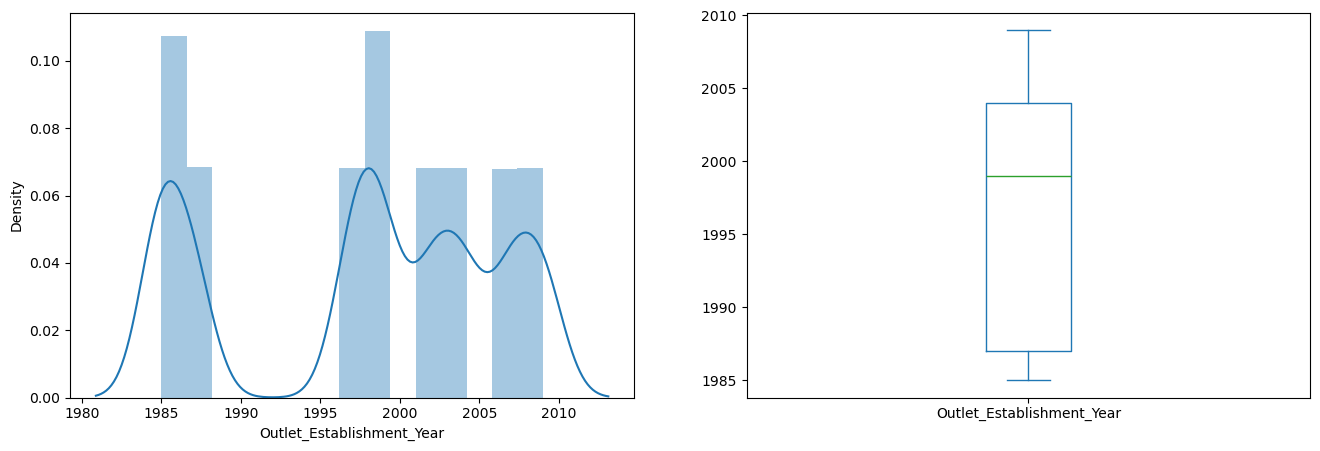

In [23]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['Outlet_Establishment_Year'])

plt.subplot(122)
train['Outlet_Establishment_Year'].plot.box(figsize=(16,5))
plt.show()

C:\Users\sujit\AppData\Local\Temp\ipykernel_12716\2319110243.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Item_Outlet_Sales'])


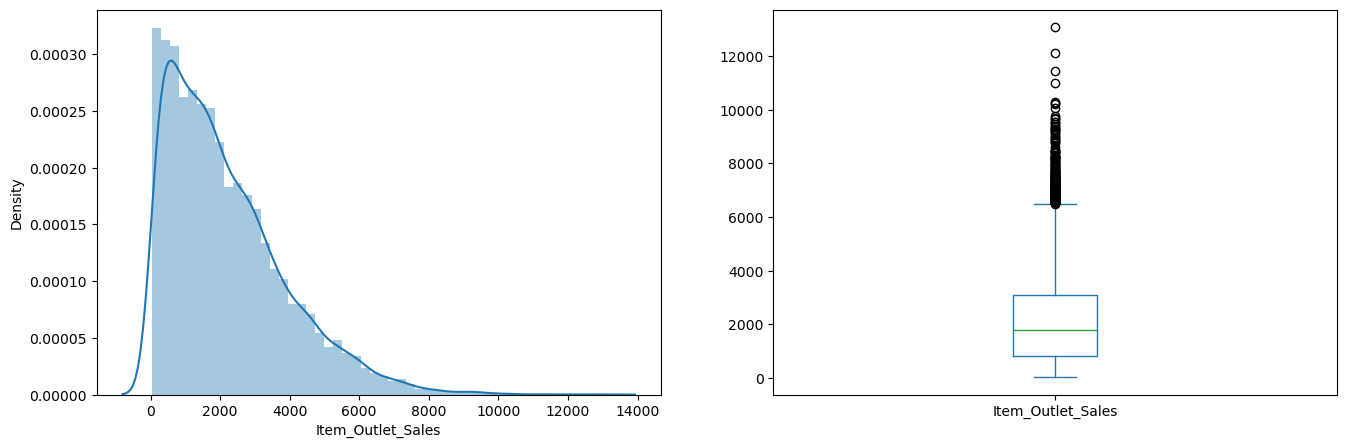

In [24]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['Item_Outlet_Sales'])

plt.subplot(122)
train['Item_Outlet_Sales'].plot.box(figsize=(16,5))
plt.show()

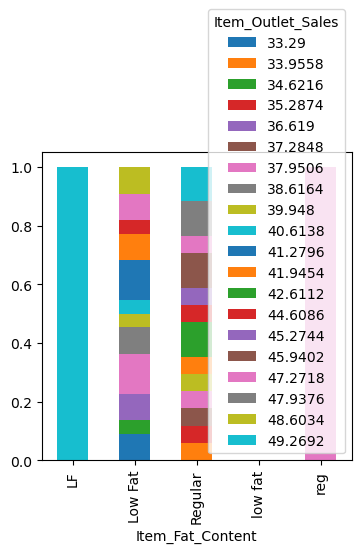

In [25]:
Item_Fat_Content=pd.crosstab(train['Item_Fat_Content'],train['Item_Outlet_Sales'])
Item_Fat_Content = Item_Fat_Content.iloc[:, :20]
Item_Fat_Content.div(Item_Fat_Content.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True,figsize=(4,4))
plt.show()

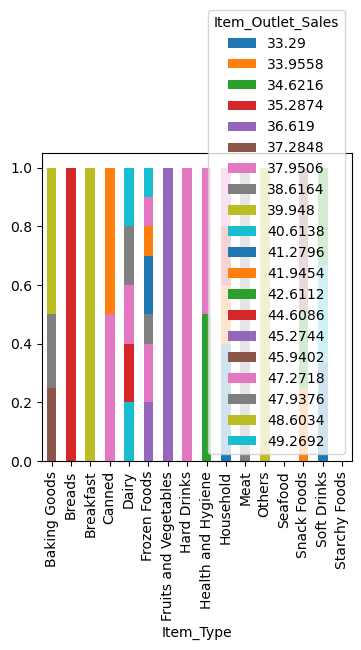

In [26]:
Item_Type=pd.crosstab(train['Item_Type'],train['Item_Outlet_Sales'])
Item_Type= Item_Type.iloc[:, :20]
Item_Type.div(Item_Type.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True,figsize=(4,4))
plt.show()

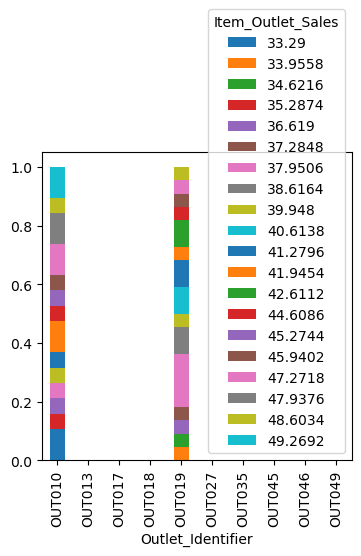

In [27]:
Outlet_Identifier=pd.crosstab(train['Outlet_Identifier'],train['Item_Outlet_Sales'])
Outlet_Identifier= Outlet_Identifier.iloc[:, :20]
Outlet_Identifier.div(Outlet_Identifier.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True,figsize=(4,4))
plt.show()

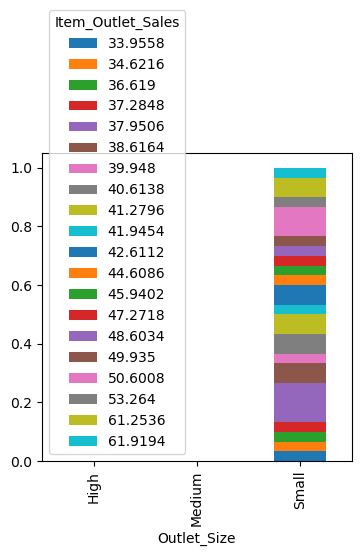

In [29]:
Outlet_Size=pd.crosstab(train['Outlet_Size'],train['Item_Outlet_Sales'])
Outlet_Size=Outlet_Size.iloc[:, :20]
Outlet_Size.div(Outlet_Size.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True,figsize=(4,4))
plt.show()

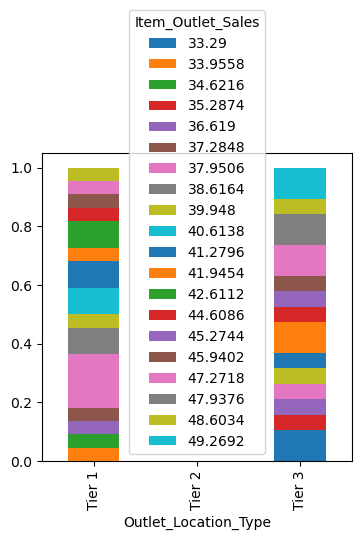

In [30]:
Outlet_Location_Type=pd.crosstab(train['Outlet_Location_Type'],train['Item_Outlet_Sales'])
Outlet_Location_Type=Outlet_Location_Type.iloc[:, :20]
Outlet_Location_Type.div(Outlet_Location_Type.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True,figsize=(4,4))
plt.show()

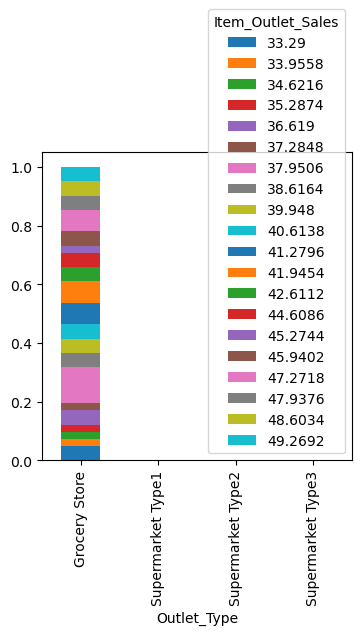

In [31]:
Outlet_Type=pd.crosstab(train['Outlet_Type'],train['Item_Outlet_Sales'])
Outlet_Type= Outlet_Type.iloc[:, :20]
Outlet_Type.div(Outlet_Type.sum(1).astype(float),axis=0).plot(kind="bar",stacked=True,figsize=(4,4))
plt.show()

In [32]:
train.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [34]:
train['Item_Weight'].fillna(train['Item_Weight'].mode()[0],inplace=True)

In [36]:
train['Outlet_Size'].fillna(train['Outlet_Size'].mode()[0], inplace=True)

In [37]:
train.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [42]:
test['Item_Weight'] = test['Item_Weight'].fillna(test['Item_Weight'].mode()[0])

In [43]:
test['Outlet_Size'] = test['Outlet_Size'].fillna(test['Outlet_Size'].mode()[0])

In [44]:
train=train.drop('Item_Identifier',axis=1)
test=test.drop('Item_Identifier',axis=1)

In [60]:
train=train.drop('Outlet_Identifier',axis=1)
test=test.drop('Outlet_Identifier',axis=1)

KeyError: "['Outlet_Identifier'] not found in axis"

In [46]:
X=train.drop('Item_Outlet_Sales',axis=1)
Y=train.Item_Outlet_Sales

In [47]:
X=pd.get_dummies(X)
train=pd.get_dummies(train)
test=pd.get_dummies(test)

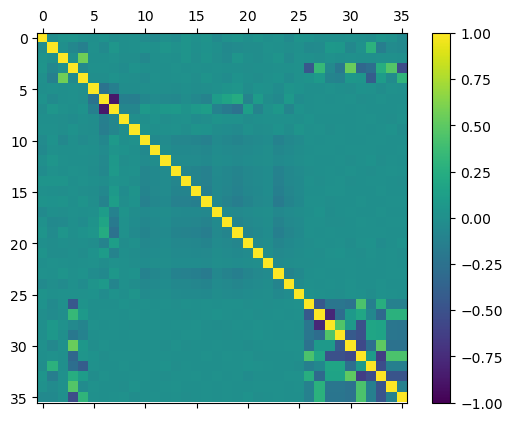

In [48]:
fig=plt.figure()
ax=fig.add_subplot(111)
cax=ax.matshow(train.corr(),vmin=-1,vmax=1)
fig.colorbar(cax)
plt.show()

In [56]:
x_train, x_cv, y_train, y_cv=train_test_split(X,Y, test_size =0.3)   
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
RandomForestRegressor()

RandomForestRegressor()

In [57]:
pred_cv= model.predict(x_cv)
mean_squared_error(y_cv,pred_cv)

1343494.5093329179

In [58]:
pred_test=model.predict(test)

In [59]:
submission=pd.read_csv("C:/python/DMart/SampleSubmission.csv")

In [61]:
submission['Item_Outlet_Sales']=pred_test
submission['Item_Identifier']=test_original['Item_Identifier']
submission['Outlet_Identifier']=test_original['Outlet_Identifier']

In [62]:
pd.DataFrame(submission,columns=['Item_Identifier','Outlet_Identifier','Item_Outlet_Sales']).to_csv('log.csv')